# Baseline-Ready Preprocessing

This notebook converts FD001 raw and selected features into leakage-safe, model-ready training, validation, and test datasets for baseline modelling. It implements engine-level train/validation splitting, scaling fitted only on training data, RUL capping, and produces Feature Set A (full raw), Feature Set B (filtered raw), and Feature Set C (filtered + derived degradation features).

## 1. Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

DATA_DIR = '../data/raw/CMAPSS/'
PROCESSED_DIR = '../data/processed/'
FIG_DIR = '../reports/figures/'
TBL_DIR = '../reports/tables/'

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(TBL_DIR, exist_ok=True)

## 2. Load FD001 Data with RUL

In [2]:
# Column schema
index_cols = ['unit_number', 'time_in_cycles']
op_cols = [f'operational_setting_{i}' for i in range(1, 4)]
sensor_cols = [f'sensor_measurement_{i}' for i in range(1, 22)]
all_cols = index_cols + op_cols + sensor_cols

# Load data
train_df = pd.read_csv(f'{DATA_DIR}train_FD001.txt', sep='\\s+', header=None, names=all_cols)
test_df = pd.read_csv(f'{DATA_DIR}test_FD001.txt', sep='\\s+', header=None, names=all_cols)
rul_df = pd.read_csv(f'{DATA_DIR}RUL_FD001.txt', sep='\\s+', header=None, names=['RUL'])

# Train RUL
max_cycles = train_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
max_cycles.columns = ['unit_number', 'max_cycle']
train_df = train_df.merge(max_cycles, on='unit_number', how='left')
train_df['RUL'] = train_df['max_cycle'] - train_df['time_in_cycles']
train_df.drop(columns=['max_cycle'], inplace=True)

# Test RUL
test_max_cycles = test_df.groupby('unit_number')['time_in_cycles'].max().reset_index()
test_max_cycles.columns = ['unit_number', 'last_test_cycle']
rul_df_indexed = rul_df.copy()
rul_df_indexed['unit_number'] = range(1, len(rul_df) + 1)
test_max_cycles = test_max_cycles.merge(rul_df_indexed, on='unit_number', how='left')
test_max_cycles['estimated_failure_cycle'] = test_max_cycles['last_test_cycle'] + test_max_cycles['RUL']
test_df = test_df.merge(
    test_max_cycles[['unit_number', 'estimated_failure_cycle']],
    on='unit_number', how='left'
)
test_df['RUL'] = test_df['estimated_failure_cycle'] - test_df['time_in_cycles']
test_df.drop(columns=['estimated_failure_cycle'], inplace=True)

print(f'Train: {train_df.shape}, Test: {test_df.shape}')
print(f'Train RUL range: [{train_df["RUL"].min()}, {train_df["RUL"].max()}]')
print(f'Test RUL range:  [{test_df["RUL"].min()}, {test_df["RUL"].max()}]')

Train: (20631, 27), Test: (13096, 27)
Train RUL range: [0, 361]
Test RUL range:  [7, 340]


## 3. Define Feature Sets

Load the selected features from Step 2 and define three feature sets.

In [3]:
# Load selected features from Step 2
selected_features_df = pd.read_csv(f'{TBL_DIR}selected_features_fd001.csv')
selected_sensor_features = selected_features_df['feature'].tolist()

# Feature Set A: Full raw (all operational settings + all 21 sensors)
feature_set_a = op_cols + sensor_cols

# Feature Set B: Filtered raw (14 selected variable sensors)
feature_set_b = selected_sensor_features

# Feature Set C: Filtered + derived (built later in this notebook)
# Will be extended after deriving degradation features

print(f'Feature Set A (full raw):  {len(feature_set_a)} features')
print(f'Feature Set B (filtered):  {len(feature_set_b)} features')
print(f'Feature Set B: {feature_set_b}')

Feature Set A (full raw):  24 features
Feature Set B (filtered):  14 features
Feature Set B: ['sensor_measurement_11', 'sensor_measurement_4', 'sensor_measurement_12', 'sensor_measurement_7', 'sensor_measurement_15', 'sensor_measurement_21', 'sensor_measurement_20', 'sensor_measurement_2', 'sensor_measurement_17', 'sensor_measurement_3', 'sensor_measurement_8', 'sensor_measurement_13', 'sensor_measurement_9', 'sensor_measurement_14']


## 4. RUL Capping

Very high early-life RUL values may dominate the learning objective even though precise differences in the early healthy stage are less important for degradation modelling. Capping RUL at a maximum value focuses the model on the degradation region where prediction matters.

A cap of 125 cycles is often used in C-MAPSS RUL experiments and is adopted here for the initial baseline pipeline. This means:
- If actual RUL > 125, the target is set to 125.
- If actual RUL <= 125, the target remains unchanged.

This is applied to both training and test targets.

In [4]:
RUL_CAP = 125

train_df['RUL_capped'] = train_df['RUL'].clip(upper=RUL_CAP)
test_df['RUL_capped'] = test_df['RUL'].clip(upper=RUL_CAP)

print(f'RUL cap applied at {RUL_CAP} cycles')
print(f'Train RUL_capped range: [{train_df["RUL_capped"].min()}, {train_df["RUL_capped"].max()}]')
print(f'Test RUL_capped range:  [{test_df["RUL_capped"].min()}, {test_df["RUL_capped"].max()}]')
print()
print(f'Rows with RUL > {RUL_CAP} in training: {(train_df["RUL"] > RUL_CAP).sum()} '
      f'({(train_df["RUL"] > RUL_CAP).mean()*100:.1f}%)')

RUL cap applied at 125 cycles
Train RUL_capped range: [0, 125]
Test RUL_capped range:  [7, 125]

Rows with RUL > 125 in training: 8031 (38.9%)


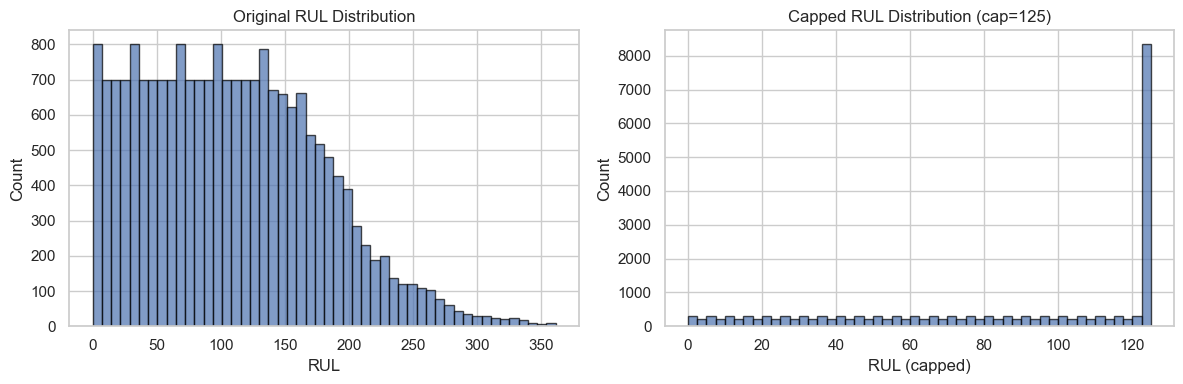

In [5]:
# Visualize effect of RUL capping
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(train_df['RUL'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('RUL')
axes[0].set_ylabel('Count')
axes[0].set_title('Original RUL Distribution')

axes[1].hist(train_df['RUL_capped'], bins=50, edgecolor='black', alpha=0.7)
axes[1].set_xlabel('RUL (capped)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Capped RUL Distribution (cap={RUL_CAP})')

plt.tight_layout()
plt.savefig(f'{FIG_DIR}rul_capping_comparison_fd001.png', dpi=150)
plt.show()

## 5. Engine-Level Train/Validation Split

To avoid data leakage from temporal or unit-level correlation, the split is done at the engine level. Entire engine trajectories go to either training or validation. No row-level random splitting is used.

Split ratio: 80% training engines, 20% validation engines.

In [6]:
# Engine-level split
all_units = train_df['unit_number'].unique()
n_units = len(all_units)

np.random.seed(42)
shuffled_units = np.random.permutation(all_units)

n_train = int(0.8 * n_units)
train_units = shuffled_units[:n_train]
val_units = shuffled_units[n_train:]

train_split = train_df[train_df['unit_number'].isin(train_units)].copy()
val_split = train_df[train_df['unit_number'].isin(val_units)].copy()

print(f'Total engines: {n_units}')
print(f'Training engines: {len(train_units)} ({len(train_units)/n_units*100:.0f}%)')
print(f'Validation engines: {len(val_units)} ({len(val_units)/n_units*100:.0f}%)')
print(f'Training rows: {len(train_split)}')
print(f'Validation rows: {len(val_split)}')
print(f'Test rows: {len(test_df)}')

Total engines: 100
Training engines: 80 (80%)
Validation engines: 20 (20%)
Training rows: 16340
Validation rows: 4291
Test rows: 13096


## 6. Feature Scaling

StandardScaler is fitted only on the training split. The same scaler is applied to validation and test data. This prevents information leakage from validation/test into the scaling parameters.

In [7]:
# Fit scaler on training split only
scaler_a = StandardScaler()
scaler_a.fit(train_split[feature_set_a])

scaler_b = StandardScaler()
scaler_b.fit(train_split[feature_set_b])

# Apply scaling
# Feature Set A
train_a = train_split.copy()
val_a = val_split.copy()
test_a = test_df.copy()

train_a[feature_set_a] = scaler_a.transform(train_split[feature_set_a])
val_a[feature_set_a] = scaler_a.transform(val_split[feature_set_a])
test_a[feature_set_a] = scaler_a.transform(test_df[feature_set_a])

# Feature Set B
train_b = train_split.copy()
val_b = val_split.copy()
test_b = test_df.copy()

train_b[feature_set_b] = scaler_b.transform(train_split[feature_set_b])
val_b[feature_set_b] = scaler_b.transform(val_split[feature_set_b])
test_b[feature_set_b] = scaler_b.transform(test_df[feature_set_b])

print('Scaling applied (fitted on training split only).')
print(f'Feature Set A scaled: train={train_a.shape}, val={val_a.shape}, test={test_a.shape}')
print(f'Feature Set B scaled: train={train_b.shape}, val={val_b.shape}, test={test_b.shape}')

Scaling applied (fitted on training split only).
Feature Set A scaled: train=(16340, 28), val=(4291, 28), test=(13096, 28)
Feature Set B scaled: train=(16340, 28), val=(4291, 28), test=(13096, 28)


## 7. Derived Degradation Features (Feature Set C)

Compute degradation-related derived features for each engine using the filtered sensor set. These capture how sensors change over time, rather than just their instantaneous values.

Derived features:
- Rolling mean (window=5)
- Rolling standard deviation (window=5)
- Delta from initial value (current - first cycle value)
- Normalized cycle age (time_in_cycles / max_cycle_for_unit)

In [8]:
ROLLING_WINDOW = 5

def compute_derived_features(df, sensor_features, window=ROLLING_WINDOW):
    """Compute derived degradation features per engine unit."""
    derived_dfs = []

    for unit in df['unit_number'].unique():
        unit_data = df[df['unit_number'] == unit].copy()

        for sensor in sensor_features:
            # Rolling mean
            unit_data[f'{sensor}_rmean'] = (
                unit_data[sensor].rolling(window=window, min_periods=1).mean()
            )
            # Rolling std
            unit_data[f'{sensor}_rstd'] = (
                unit_data[sensor].rolling(window=window, min_periods=1).std().fillna(0)
            )
            # Delta from initial value
            initial_val = unit_data[sensor].iloc[0]
            unit_data[f'{sensor}_delta'] = unit_data[sensor] - initial_val

        # Cycle index as a separate model feature (avoids collision with metadata time_in_cycles)
        unit_data['cycle_index'] = unit_data['time_in_cycles']

        derived_dfs.append(unit_data)

    return pd.concat(derived_dfs, ignore_index=True)

print(f'Computing derived features with rolling window={ROLLING_WINDOW}...')

train_c_raw = compute_derived_features(train_split, feature_set_b)
val_c_raw = compute_derived_features(val_split, feature_set_b)
test_c_raw = compute_derived_features(test_df, feature_set_b)

# Identify derived feature columns
derived_cols = [c for c in train_c_raw.columns if c.endswith(('_rmean', '_rstd', '_delta'))]
derived_cols.append('cycle_index')

feature_set_c = feature_set_b + derived_cols

print(f'Derived features computed: {len(derived_cols)} new columns')
print(f'Feature Set C total: {len(feature_set_c)} features')
print(f'  Raw sensors: {len(feature_set_b)}')
print(f'  Derived + temporal: {len(derived_cols)}')

Computing derived features with rolling window=5...


Derived features computed: 43 new columns
Feature Set C total: 57 features
  Raw sensors: 14
  Derived + temporal: 43


In [9]:
# Scale Feature Set C
scaler_c = StandardScaler()
scaler_c.fit(train_c_raw[feature_set_c])

train_c = train_c_raw.copy()
val_c = val_c_raw.copy()
test_c = test_c_raw.copy()

train_c[feature_set_c] = scaler_c.transform(train_c_raw[feature_set_c])
val_c[feature_set_c] = scaler_c.transform(val_c_raw[feature_set_c])
test_c[feature_set_c] = scaler_c.transform(test_c_raw[feature_set_c])

print('Feature Set C scaling applied.')
print(f'Feature Set C scaled: train={train_c.shape}, val={val_c.shape}, test={test_c.shape}')

Feature Set C scaling applied.
Feature Set C scaled: train=(16340, 71), val=(4291, 71), test=(13096, 71)


## 8. Prepare Final Tabular Datasets

Extract the final X (features) and y (target) arrays for each feature set and split.

In [10]:
TARGET_COL = 'RUL_capped'

# Feature Set A
X_train_a = train_a[feature_set_a].values
X_val_a = val_a[feature_set_a].values
X_test_a = test_a[feature_set_a].values
y_train_a = train_a[TARGET_COL].values
y_val_a = val_a[TARGET_COL].values
y_test_a = test_a[TARGET_COL].values

# Feature Set B
X_train_b = train_b[feature_set_b].values
X_val_b = val_b[feature_set_b].values
X_test_b = test_b[feature_set_b].values
y_train_b = train_b[TARGET_COL].values
y_val_b = val_b[TARGET_COL].values
y_test_b = test_b[TARGET_COL].values

# Feature Set C
X_train_c = train_c[feature_set_c].values
X_val_c = val_c[feature_set_c].values
X_test_c = test_c[feature_set_c].values
y_train_c = train_c[TARGET_COL].values
y_val_c = val_c[TARGET_COL].values
y_test_c = test_c[TARGET_COL].values

print('Tabular datasets prepared:')
print(f'  Set A: X_train={X_train_a.shape}, X_val={X_val_a.shape}, X_test={X_test_a.shape}')
print(f'  Set B: X_train={X_train_b.shape}, X_val={X_val_b.shape}, X_test={X_test_b.shape}')
print(f'  Set C: X_train={X_train_c.shape}, X_val={X_val_c.shape}, X_test={X_test_c.shape}')
print(f'  Target: y_train={y_train_a.shape}, y_val={y_val_a.shape}, y_test={y_test_a.shape}')

Tabular datasets prepared:
  Set A: X_train=(16340, 24), X_val=(4291, 24), X_test=(13096, 24)
  Set B: X_train=(16340, 14), X_val=(4291, 14), X_test=(13096, 14)
  Set C: X_train=(16340, 57), X_val=(4291, 57), X_test=(13096, 57)
  Target: y_train=(16340,), y_val=(4291,), y_test=(13096,)


## 9. Save Processed Datasets

Save processed DataFrames and metadata for reuse in baseline modelling notebooks.

In [11]:
# Save processed DataFrames
train_a[feature_set_a + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}train_a_fd001.csv', index=False)
val_a[feature_set_a + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}val_a_fd001.csv', index=False)
test_a[feature_set_a + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}test_a_fd001.csv', index=False)

train_b[feature_set_b + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}train_b_fd001.csv', index=False)
val_b[feature_set_b + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}val_b_fd001.csv', index=False)
test_b[feature_set_b + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}test_b_fd001.csv', index=False)

train_c[feature_set_c + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}train_c_fd001.csv', index=False)
val_c[feature_set_c + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}val_c_fd001.csv', index=False)
test_c[feature_set_c + ['unit_number', 'time_in_cycles', 'RUL', TARGET_COL]].to_csv(
    f'{PROCESSED_DIR}test_c_fd001.csv', index=False)

print('Processed datasets saved to:', PROCESSED_DIR)
for f in sorted(os.listdir(PROCESSED_DIR)):
    if f.endswith('.csv'):
        size_kb = os.path.getsize(f'{PROCESSED_DIR}{f}') / 1024
        print(f'  {f} ({size_kb:.0f} KB)')

Processed datasets saved to: ../data/processed/
  test_a_fd001.csv (5556 KB)
  test_b_fd001.csv (3713 KB)
  test_c_fd001.csv (14581 KB)
  train_a_fd001.csv (6902 KB)
  train_b_fd001.csv (4602 KB)
  train_c_fd001.csv (18114 KB)
  train_val_split_fd001.csv (1 KB)
  val_a_fd001.csv (1814 KB)
  val_b_fd001.csv (1210 KB)
  val_c_fd001.csv (4760 KB)


## 10. Save Preprocessing Metadata

Record split assignments and feature set definitions for reproducibility.

In [12]:
# Save train/val unit assignments
split_info = pd.DataFrame({
    'unit_number': np.concatenate([train_units, val_units]),
    'split': ['train'] * len(train_units) + ['val'] * len(val_units)
})
split_info.to_csv(f'{PROCESSED_DIR}train_val_split_fd001.csv', index=False)

# Save feature set definitions
feature_sets_info = {
    'feature_set_a': feature_set_a,
    'feature_set_b': feature_set_b,
    'feature_set_c': feature_set_c,
}

# Save as a simple text record
with open(f'{PROCESSED_DIR}feature_sets_fd001.txt', 'w') as f:
    for name, features in feature_sets_info.items():
        f.write(f'{name}: {len(features)} features\n')
        for feat in features:
            f.write(f'  {feat}\n')
        f.write('\n')

print('Metadata saved:')
print(f'  {PROCESSED_DIR}train_val_split_fd001.csv')
print(f'  {PROCESSED_DIR}feature_sets_fd001.txt')
print()
print(f'RUL cap: {RUL_CAP}')
print(f'Scaler: StandardScaler (fitted on training split only)')
print(f'Split: 80/20 engine-level, seed=42')

Metadata saved:
  ../data/processed/train_val_split_fd001.csv
  ../data/processed/feature_sets_fd001.txt

RUL cap: 125
Scaler: StandardScaler (fitted on training split only)
Split: 80/20 engine-level, seed=42


## 11. Preprocessing Summary

| Step | Detail |
|---|---|
| RUL capping | Cap at 125 cycles |
| Train/val split | 80/20 engine-level, random seed=42 |
| Scaling | StandardScaler fitted on training split only |
| Feature Set A | 24 features (3 op settings + 21 sensors) |
| Feature Set B | 14 features (filtered variable sensors) |
| Feature Set C | 14 raw + derived (rolling mean, rolling std, delta, time_in_cycles) |
| Target | RUL_capped |
| Leakage prevention | Engine-level split, scaler fitted on train only, no per-unit future info in features |

These processed datasets will be used for the initial baseline modelling experiments.

In [13]:
print("Generated processed files:")
for f in sorted(os.listdir(PROCESSED_DIR)):
    print("-", f)

print("\nGenerated figures:")
for f in sorted(os.listdir(FIG_DIR)):
    print("-", f)

Generated processed files:
- .gitkeep
- feature_sets_fd001.txt
- test_a_fd001.csv
- test_b_fd001.csv
- test_c_fd001.csv
- train_a_fd001.csv
- train_b_fd001.csv
- train_c_fd001.csv
- train_val_split_fd001.csv
- val_a_fd001.csv
- val_b_fd001.csv
- val_c_fd001.csv

Generated figures:
- .gitkeep
- correlation_heatmap_fd001.png
- cycle_count_distribution_fd001.png
- feature_correlation_ranking_fd001.png
- rul_capping_comparison_fd001.png
- rul_distribution_fd001.png
- sample_rul_curves_fd001.png
- sample_sensor_trends_fd001.png
- sensor_trends_selected_fd001.png
- sensor_vs_rul_selected_fd001.png
